# Tóm tắt thực nghiệm ECG Bayesian CNN-LSTM

Notebook này chỉ tổng hợp kết quả đã sinh từ pipeline. Nếu chưa có kết quả, cần chạy `python main.py --mode all` trước

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
metrics_path = ROOT / 'outputs' / 'metrics' / 'model_comparison.csv'
figures_dir = ROOT / 'outputs' / 'figures' 
test_csv = ROOT / 'data' / 'raw' / 'mitbih_test.csv'
metrics_path

WindowsPath('a:/DoAn/TH_DeepLearning/Bai2/Code bài 2/N7_Bai2_ECG_Bayesian_CNN_LSTM/outputs/metrics/model_comparison.csv')

## Bảng metrics

In [2]:
if metrics_path.exists():
    comparison = pd.read_csv(metrics_path)
    display(comparison)
else:
    print('Chưa có model_comparison.csv. Hãy chạy python main.py --mode all trước.')

,model_name,loss,accuracy,precision_macro,recall_macro,f1_macro,inference_time_seconds,inference_time_per_sample_ms,mean_confidence,mean_uncertainty,high_confidence_ratio,medium_confidence_ratio,low_confidence_ratio
0,cnn_baseline,0.342800,0.866755,0.641506,0.897798,0.690723,0.569971,0.026036,NaN,NaN,NaN,NaN,NaN
1,cnn_bilstm_attention,0.185598,0.936644,0.709102,0.935955,0.772067,0.672909,0.030738,NaN,NaN,NaN,NaN,NaN
2,bayesian_cnn_bilstm_attention,0.222203,0.922711,0.700940,0.927431,0.763569,0.676841,0.030917,0.874515,0.234737,0.619724,0.26987,0.110406


## Biểu đồ đã xuất

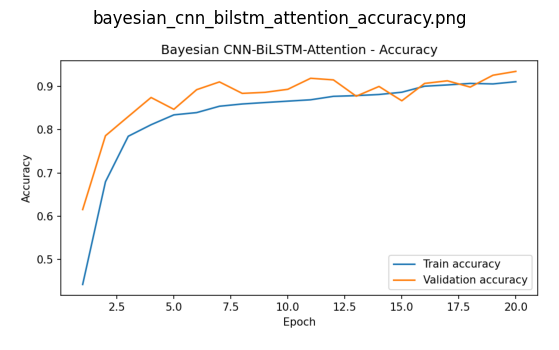

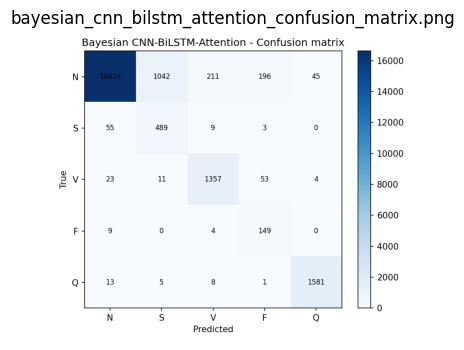

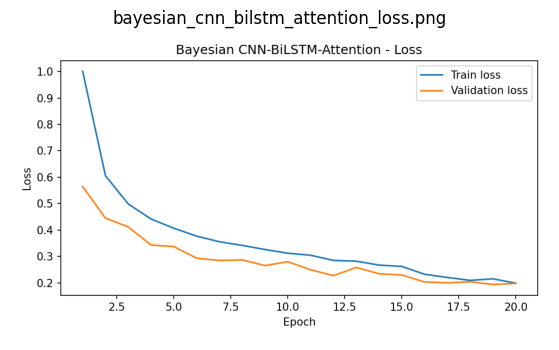

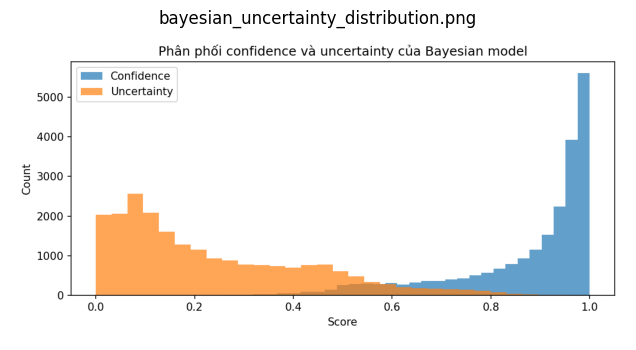

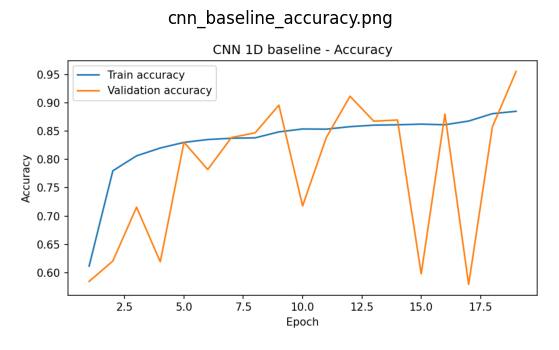

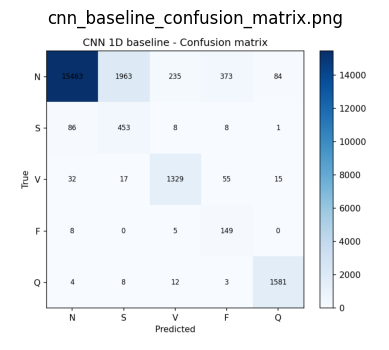

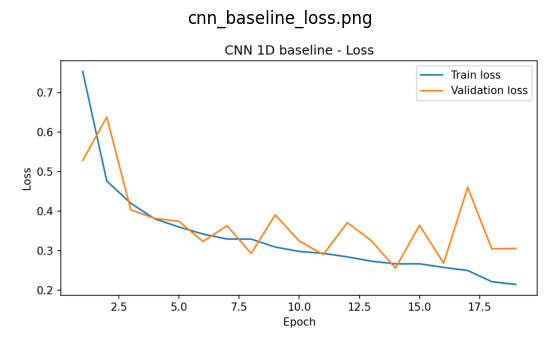

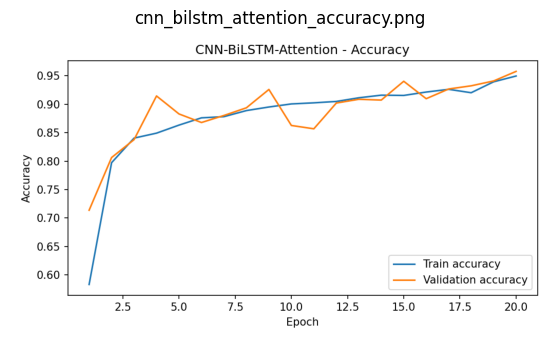

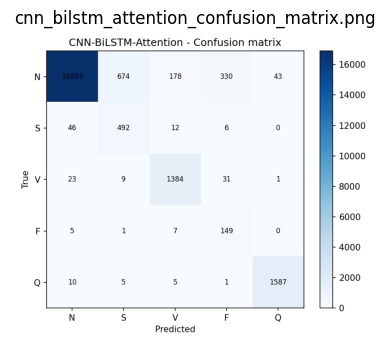

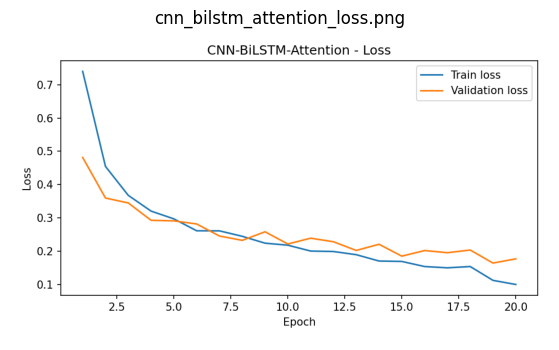

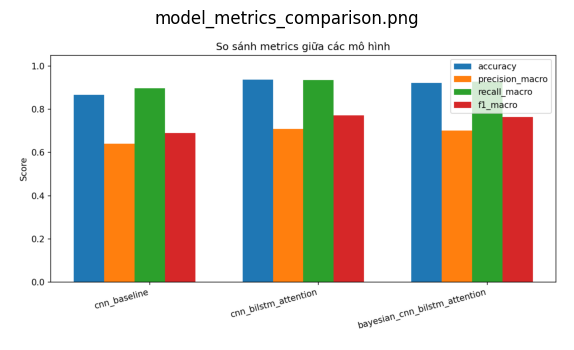

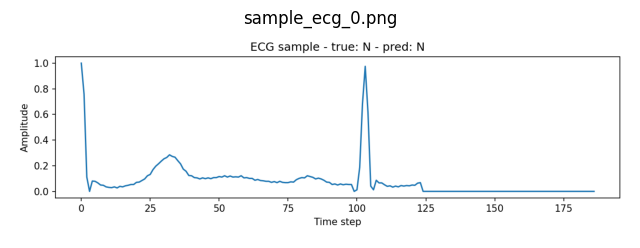

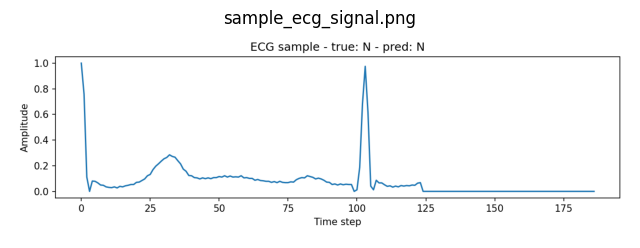

In [3]:
figures = sorted(figures_dir.glob('*.png'))
if not figures:
    print('Chưa có hình trong outputs/figures. Hãy chạy python main.py --mode visualize sau khi train/evaluate.')
for figure in figures:
    image = plt.imread(figure)
    plt.figure(figsize=(8, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(figure.name)
    plt.show()

## Một mẫu tín hiệu ECG từ test set

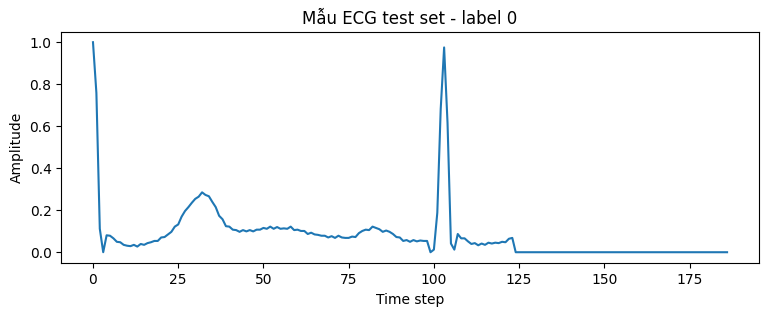

In [4]:
if test_csv.exists():
    sample = pd.read_csv(test_csv, header=None, nrows=1).iloc[0]
    signal = sample.iloc[:187].to_numpy(dtype='float32')
    label = int(sample.iloc[187])
    plt.figure(figsize=(9, 3))
    plt.plot(signal)
    plt.title(f'Mẫu ECG test set - label {label}')
    plt.xlabel('Time step')
    plt.ylabel('Amplitude')
    plt.show()
else:
    print('Chưa có mitbih_test.csv trong data/raw/.')